Using neuroCombat, harmonizing variables that we want to "clean out" of the data 

In [2]:
import pandas as pd
import neuroCombat
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
print(df.columns)

Index(['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3',
       'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob',
       'gm_volume_cm3', 'protocol', 'birth_year', 'Unnamed: 0', 'atlas_name',
       'scan_time', 'age_at_scan', 'weight', 'directory_path',
       'estimated_critical_info', 'scan_date', 'file_path',
       'classification_label'],
      dtype='object')


In [11]:
tested_batch = 'manufacturer'  # Column indicating the batch variable

1. Data Matrix (df_features) - rows are imaging features (454 brain regions) and columns are individual scans (subjects).
2. Covariate Table (df_covariates)- row is a subject and columns include:
    a. Batch ID: The unique identifier for the scanner/site.
    b. Biological Covariates: Variables you want to protect (Age, Sex, Diagnosis).

In [12]:
# df_features has regions as columns (454) and subjects as rows (1000+), and the data is volume measurements
df_features = df.pivot_table(
    index='subject_id', 
    columns='region_label', 
    values='volume_mm3', 
    aggfunc='mean' # or 'sum', etc.
)

# index is subject_id, order them 
df_features = df_features.sort_index()

df_covariates = df.drop_duplicates(subset=['subject_id'])[
    ['subject_id', 'sex', 'institute', 'manufacturer', 'age_in_years',  'birth_year']] # add protocol and tiv, but notice they're missing for some subjects

# index is subject_id, order them 
df_covariates = df_covariates.set_index('subject_id').sort_index()

# validate alignment
print("Covariates Index (first 5):", df_covariates.index[:5].tolist())
print("Before Features Index (first 5):", df_features.index[:5].tolist())

Covariates Index (first 5): ['0873', 'BB00005', 'BB01209', 'BBK0001', 'BBK0002']
Before Features Index (first 5): ['0873', 'BB00005', 'BB01209', 'BBK0001', 'BBK0002']


# Before Harmonization


1. check collinearity between the batch and the features, to make sure I don't harmonize features (brain volume)
 If they overlap (earlier birth years correlation with institute = 1 I have collinearity and harmonizing can harm the biological effect)

In [13]:
from scipy.stats import chi2_contingency
# Check if Diagnosis is confounded with Institute
confound_check = pd.crosstab(df_covariates[tested_batch], df_covariates['birth_year'])
print(confound_check)

chi2, p, dof, ex = chi2_contingency(confound_check)
print(f"Chi-square p-value: {p}")

birth_year          1900  1911  1912  1917  1919  1921  1922  1924  1925  \
manufacturer                                                               
GE MEDICAL SYSTEMS     1     1     1     1     1     1     2     1     3   
SIEMENS                0     0     0     0     0     0     0     0     0   

birth_year          1926  ...  2001  2002  2003  2004  2005  2006  2007  2013  \
manufacturer              ...                                                   
GE MEDICAL SYSTEMS     1  ...     0     0     0     0     0     0     0     0   
SIEMENS                0  ...   132    89    49    41    19    19     4     3   

birth_year          2014  2015  
manufacturer                    
GE MEDICAL SYSTEMS     0     0  
SIEMENS                1     1  

[2 rows x 93 columns]
Chi-square p-value: 3.0952314031864465e-188


In [ ]:
# to handle collinearity, set scans from snbb as the reference batch


2. make sure the subgroups in the batch are big enough to be meaningful

In [14]:
# how many scans are per group in a batch: (at least 20 per group)
for col in ['institute', 'manufacturer']:
    print(f"Counts for {col}:")
    print(df_covariates[col].value_counts())
    print("\n")

Counts for institute:
institute
Tel-Aviv University       3080
ICHILOV TEL AVIV           511
SHEBA_ MEDICAL_ CENTER     166
Name: count, dtype: int64


Counts for manufacturer:
manufacturer
SIEMENS               3080
GE MEDICAL SYSTEMS     677
Name: count, dtype: int64




3. look for missing values and remove them (as neuroCombat can't handle missing values)

In [15]:
# are there any missing values?
print("Missing values in df_features:", df_features.isnull().sum().sum())

# separate the entries with missing values
missing_values_features = df_features[df_features.isnull().any(axis=1)]
print("Missing values in df_covariates:", df_covariates.isnull().sum())

Missing values in df_features: 231
Missing values in df_covariates: sex             0
institute       0
manufacturer    0
age_in_years    0
birth_year      0
dtype: int64


In [16]:
# remove entries with missing values from both dataframes
df_features = df_features.dropna()
df_covariates = df_covariates.loc[df_features.index]

# Running harmonization

--- Batch Size Summary ---
super_batch
Tel-Aviv University_SIEMENS                  3079
ICHILOV TEL AVIV_GE MEDICAL SYSTEMS           508
SHEBA_ MEDICAL_ CENTER_GE MEDICAL SYSTEMS     166
Name: count, dtype: int64

--- Confounding Check (Batch vs. Age) ---
ANOVA F-statistic: 92.1466
ANOVA p-value: 0.0000
ALERT: Strong confounding detected. Mean age differs significantly across batches.
NeuroCombat will need to work harder to separate aging from scanner effects.


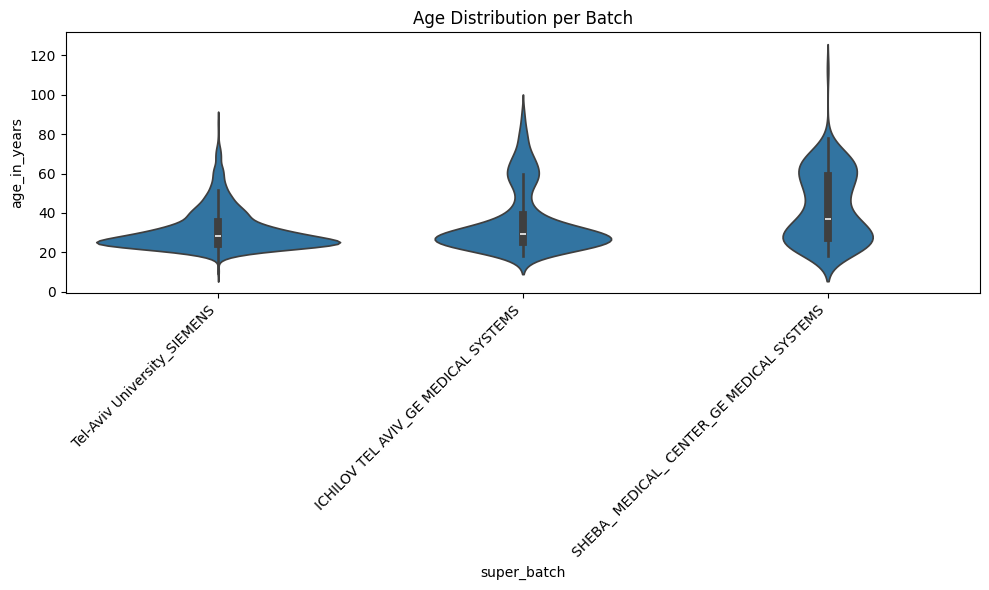

In [25]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the Super-Batch ID
df_covariates['super_batch'] = (
    df_covariates['institute'].astype(str) + "_" + 
    df_covariates['manufacturer'].astype(str)
)

# 2. Count subjects per batch
batch_counts = df_covariates['super_batch'].value_counts()
print("--- Batch Size Summary ---")
print(batch_counts)

small_batches = batch_counts[batch_counts < 5].index.tolist()
if small_batches:
    print(f"\nWarning: Batches with < 5 subjects: {small_batches}")

# 3. Check for Continuous Confounding (ANOVA)
print("\n--- Confounding Check (Batch vs. Age) ---")

# Group age data by batch
groups = [group['age_in_years'].values for name, group in df_covariates.groupby('super_batch')]

# Run One-Way ANOVA
f_stat, p_val = stats.f_oneway(*groups)

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value: {p_val:.4f}")

if p_val < 0.05:
    print("ALERT: Strong confounding detected. Mean age differs significantly across batches.")
    print("NeuroCombat will need to work harder to separate aging from scanner effects.")

# 4. Visual Diagnostic (Crucial for 2000-2025 studies)
plt.figure(figsize=(10, 6))
sns.violinplot(x='super_batch', y='age_in_years', data=df_covariates)
plt.xticks(rotation=45, ha='right')
plt.title("Age Distribution per Batch")
plt.tight_layout()
plt.show()

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

def calculate_overlap(data, batch_col, age_col, batch_a, batch_b):
    # Extract age arrays for the two batches
    age_a = data[data[batch_col] == batch_a][age_col].dropna()
    age_b = data[data[batch_col] == batch_b][age_col].dropna()
    
    # Define the range for the density estimation
    low = min(age_a.min(), age_b.min())
    high = max(age_a.max(), age_b.max())
    x = np.linspace(low, high, 1000)
    
    # Estimate Kernel Density (KDE)
    from scipy.stats import gaussian_kde
    kde_a = gaussian_kde(age_a)(x)
    kde_b = gaussian_kde(age_b)(x)
    
    # Calculate the overlap (Area under the minimum of both curves)
    overlap = np.trapz(np.minimum(kde_a, kde_b), x)
    return overlap

# Identify your oldest and newest batches (examples)
batch1 = "ICHILOV TEL AVIV_GE MEDICAL SYSTEMS" # Adjust to your actual Super-Batch names
batch2 = "Tel-Aviv University_SIEMENS"
batch3 = "SHEBA_ MEDICAL_ CENTER_GE MEDICAL SYSTEMS"
batches = [batch1, batch2, batch3]

df_covariates['age_in_years'] = pd.to_numeric(df_covariates['age_in_years'], errors='coerce')

for b1, b2 in combinations(batches, 2):
    # Get age data for the two batches being compared
    ages1 = df_covariates[df_covariates['super_batch'] == b1]['age_in_years']
    ages2 = df_covariates[df_covariates['super_batch'] == b2]['age_in_years']
    
    # Calculate overlap score
    ovl_score = calculate_overlap(df_covariates, 'super_batch', 'age_in_years', b1, b2)
    
    print(f"\nComparing {b1} vs {b2}:")
    print(f"  {b1}: Range {ages1.min():.1f}-{ages1.max():.1f} (N={len(ages1)})")
    print(f"  {b2}: Range {ages2.min():.1f}-{ages2.max():.1f} (N={len(ages2)})")
    print(f"  Overlap Score: {ovl_score:.4f}")

    # 3. Logic warnings
    if ovl_score < 0.3:
        print("  CRITICAL WARNING: Very low age overlap. Harmonization results may be biased.")
    elif ovl_score < 0.6:
        print("  CAUTION: Moderate overlap. Ensure age is correctly modeled in continuous_cols.")
    else:
        print("  GOOD: Strong overlap. Site effects can be separated from age effects.")





Comparing ICHILOV TEL AVIV_GE MEDICAL SYSTEMS vs Tel-Aviv University_SIEMENS:
  ICHILOV TEL AVIV_GE MEDICAL SYSTEMS: Range 18.0-91.0 (N=508)
  Tel-Aviv University_SIEMENS: Range 9.2-87.3 (N=3079)
  Overlap Score: 0.8267
  GOOD: Strong overlap. Site effects can be separated from age effects.

Comparing ICHILOV TEL AVIV_GE MEDICAL SYSTEMS vs SHEBA_ MEDICAL_ CENTER_GE MEDICAL SYSTEMS:
  ICHILOV TEL AVIV_GE MEDICAL SYSTEMS: Range 18.0-91.0 (N=508)
  SHEBA_ MEDICAL_ CENTER_GE MEDICAL SYSTEMS: Range 18.0-113.0 (N=166)
  Overlap Score: 0.6811
  GOOD: Strong overlap. Site effects can be separated from age effects.

Comparing Tel-Aviv University_SIEMENS vs SHEBA_ MEDICAL_ CENTER_GE MEDICAL SYSTEMS:
  Tel-Aviv University_SIEMENS: Range 9.2-87.3 (N=3079)
  SHEBA_ MEDICAL_ CENTER_GE MEDICAL SYSTEMS: Range 18.0-113.0 (N=166)
  Overlap Score: 0.6324
  GOOD: Strong overlap. Site effects can be separated from age effects.


/tmp/ipykernel_228622/136343803.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  overlap = np.trapz(np.minimum(kde_a, kde_b), x)


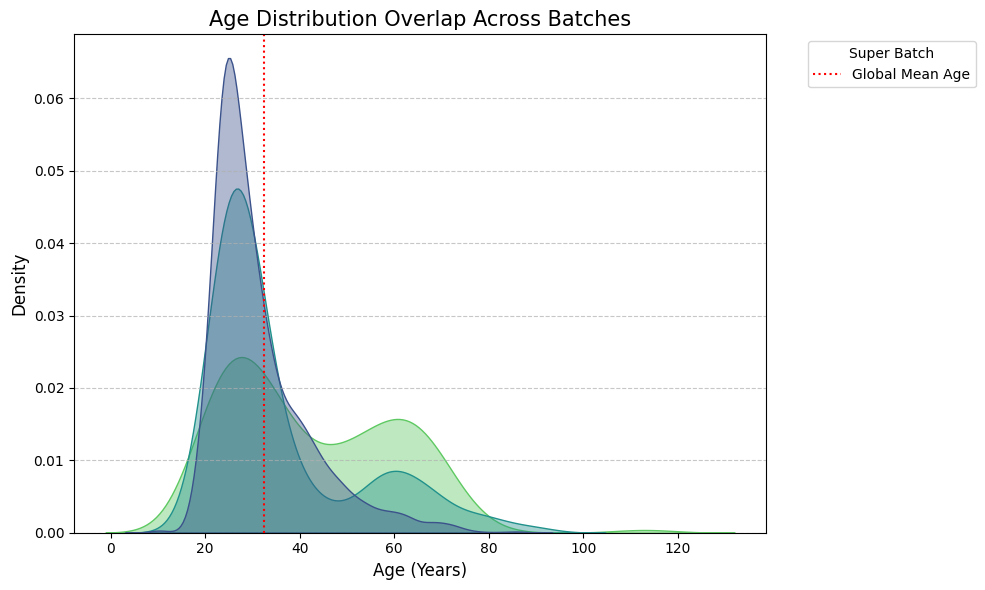

In [29]:
# visualize age distributions across batches

# 1. Prepare the data: Ensure age is numeric for the whole dataframe
df_covariates['age_in_years'] = pd.to_numeric(df_covariates['age_in_years'], errors='coerce')

plot_data = df_covariates[df_covariates['super_batch'].isin(batches)]

# 3. Create the Visualization
plt.figure(figsize=(10, 6))
sns.kdeplot(data=plot_data, x='age_in_years', hue='super_batch', 
            fill=True, common_norm=False, palette="viridis", alpha=0.4)

plt.title("Age Distribution Overlap Across Batches", fontsize=15)
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a vertical line for the mean age if helpful
plt.axvline(df_covariates['age_in_years'].mean(), color='red', linestyle=':', label='Global Mean Age')

plt.legend(title="Super Batch", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [17]:
from neuroCombat import neuroCombat
# 2. Transpose features: NeuroCombat needs (features x subjects)
# We drop the 'SubjectID' column so only numerical brain data remains
data = df_features.transpose().to_numpy()

# 3. Define the batch (scanner/site)
batch = df_covariates[tested_batch].tolist()

# 4. Define biological covariates to PRESERVE
# 'categorical_cols' tells the model these are not continuous numbers
categorical_cols = ['sex']
continuous_cols = ['age_in_years', 'birth_year']

# 5. Run NeuroCombat
# eb=True uses Empirical Bayes to pool information across features
result = neuroCombat(dat=data,
                     covars=df_covariates,
                     batch_col=tested_batch,
                     categorical_cols=categorical_cols,
                     continuous_cols=continuous_cols)

# 6. Extract the harmonized data
# The output is a dictionary; 'data' contains the corrected matrix
harmonized_data_matrix = result['data']
# convert back to DataFrame to keep track of indices and columns
harmonized_data_matrix = pd.DataFrame(harmonized_data_matrix,
                                      index=df_features.columns,
                                      columns=df_features.index)

# 7. Convert back to a DataFrame for analysis
df_harmonized = pd.DataFrame(harmonized_data_matrix.transpose(), 
                             columns=df_features.columns)

# sort indices to match original data
df_harmonized = df_harmonized.sort_index()

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


# Visualization

/tmp/ipykernel_228622/2178817581.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_before, x=tested_batch, y=target_region, ax=axes[0], palette="Set2")
/tmp/ipykernel_228622/2178817581.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_after, x=tested_batch, y=target_region, ax=axes[1], palette="Set2")


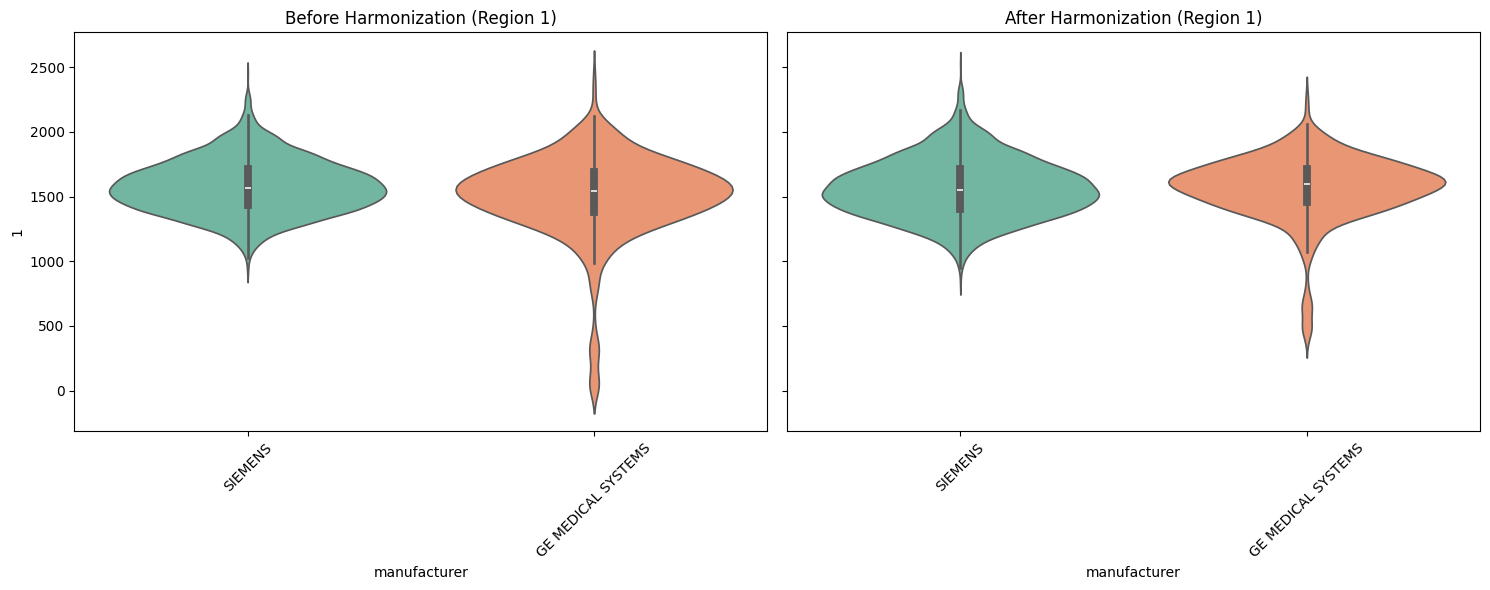

In [18]:
# pick a region to visualize (e.g., column 1)
target_region = 1 

# 1. Prepare data for plotting
# We use the index-aligned dataframes we created before NeuroCombat
plot_before = pd.concat([df_covariates[tested_batch], df_features[target_region]], axis=1)
plot_after = pd.concat([df_covariates[tested_batch], df_harmonized[target_region]], axis=1)

# 2. Create Side-by-Side Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plot Before
sns.violinplot(data=plot_before, x=tested_batch, y=target_region, ax=axes[0], palette="Set2")
axes[0].set_title(f"Before Harmonization (Region {target_region})")
axes[0].tick_params(axis='x', rotation=45)

# Plot After
sns.violinplot(data=plot_after, x=tested_batch, y=target_region, ax=axes[1], palette="Set2")
axes[1].set_title(f"After Harmonization (Region {target_region})")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()